#                              **AI4005: Mini Project**
##                      **Neuro Fuzzy C-Means Clustering Algorithm**
### Anirudh Srinivasan (CS20BTECH11059) | Ajit Shankar (ES20BTECH11003)

## Importing Libraries

In [2]:
!pip install deap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 2.8 MB/s eta 0:00:00


In [4]:
!pip install scikit-fuzzy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.0/994.0 kB 5.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-fuzzy: filename=scikit_fuzzy-0.4.2-py3-none-any.whl size=894078 sha256=90b5384abf854eb50ae4bffbdb66577a2a61f0bbb20ab3deeb5732192e6ad4d7
  Stored in directory: /root/.cache/pip/wheels/4f/86/1b/dfd97134a2c8313e519bcebd95d3fedc7be7944db022094bc8
Successfully built scikit-fuzzy


In [8]:
from deap import tools
import numpy as np
import skfuzzy as fuzz
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

## Using ANN as an feature transformer

In [11]:
# Example: fixed ANN architecture
def run_fixed_ann_and_fcm(data):
    # Define fixed ANN architecture
    hidden_layers = (10, 5, 2)

    # Scale data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Train ANN
    mlp = MLPRegressor(hidden_layer_sizes=hidden_layers, max_iter=1000)
    mlp.fit(scaled_data, scaled_data)  # Using as an autoencoder

    # Use the ANN to transform data
    transformed_data = mlp.predict(scaled_data)

    # Apply Fuzzy C-Means on the transformed data
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        transformed_data.T, 3, 2, error=0.005, maxiter=1000, init=None)

    # Evaluate clustering
    cluster_membership = np.argmax(u, axis=0)
    score = silhouette_score(transformed_data, cluster_membership)

    # Print evaluation results
    print(f"Silhouette Score of clustering: {score}")

# Generate synthetic data for demonstration
data, _ = make_blobs(n_samples=300, centers=3, n_features=5, random_state=42)

# Run the fixed ANN and FCM approach
run_fixed_ann_and_fcm(data)

Silhouette Score of clustering: 0.8142295875611189


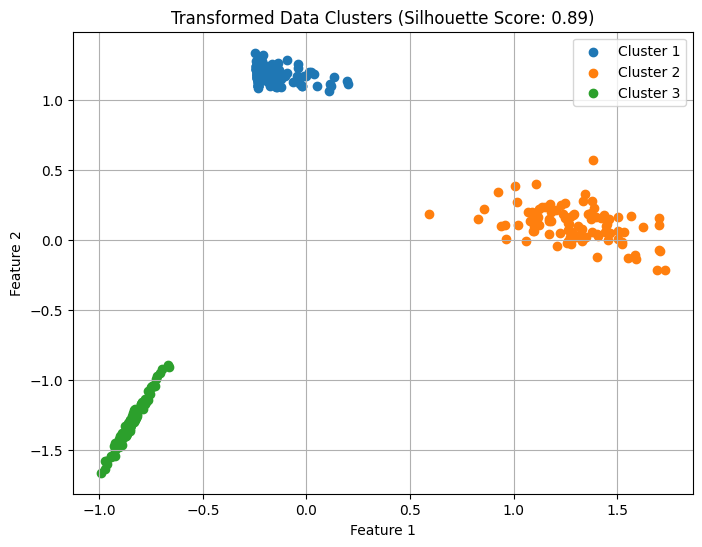

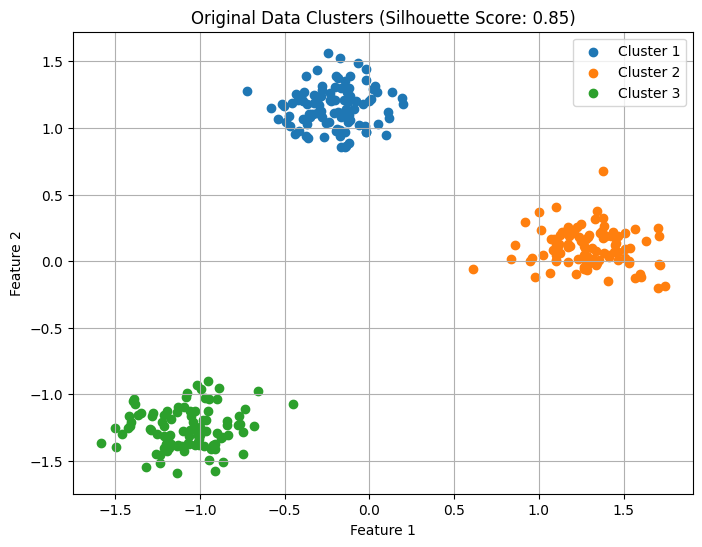

In [13]:
def plot_clusters(data, cluster_membership, title):
    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_clusters = np.unique(cluster_membership)
    for cluster in unique_clusters:
        plt.scatter(data[cluster_membership == cluster, 0], data[cluster_membership == cluster, 1], label=f'Cluster {cluster+1}')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

def apply_fcm(data, n_clusters):
    # Transpose data for skfuzzy
    data_t = data.T
    cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
        data_t, n_clusters, 2, error=0.005, maxiter=1000, init=None)
    # Hardening for silhouette score calculation
    cluster_membership = np.argmax(u, axis=0)
    score = silhouette_score(data, cluster_membership)
    return cluster_membership, score

def main():
    # Generate synthetic data for demonstration
    data, _ = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=1.0, random_state=42)

    # Normalize data
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # Train ANN as an autoencoder
    mlp = MLPRegressor(hidden_layer_sizes=(5,), max_iter=1000)
    mlp.fit(scaled_data, scaled_data)
    transformed_data = mlp.predict(scaled_data)

    # Apply Fuzzy C-Means on the transformed data
    transformed_cluster_membership, transformed_score = apply_fcm(transformed_data, 3)
    plot_clusters(transformed_data, transformed_cluster_membership, f'Transformed Data Clusters (Silhouette Score: {transformed_score:.2f})')

    # Apply Fuzzy C-Means on the original scaled data
    original_cluster_membership, original_score = apply_fcm(scaled_data, 3)
    plot_clusters(scaled_data, original_cluster_membership, f'Original Data Clusters (Silhouette Score: {original_score:.2f})')

if __name__ == '__main__':
    main()

Silhoutte score on the transformed data is better and provides better clustering results

## Using ANN as a function approximator

Silhouette Score: 0.848


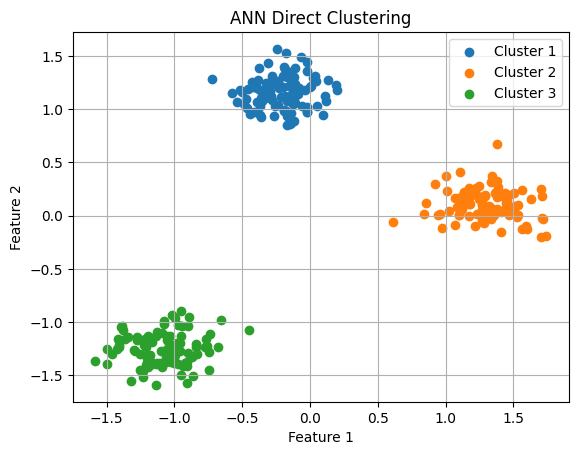

In [14]:
def plot_clusters(data, labels, title):
    fig, ax = plt.subplots()
    for cluster in np.unique(labels):
        ax.scatter(data[labels == cluster, 0], data[labels == cluster, 1], label=f'Cluster {cluster+1}')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

def main():
    # Generate synthetic data
    X, true_labels = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

    # Normalize data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Define ANN to directly output cluster memberships
    ann = MLPRegressor(hidden_layer_sizes=(10,), activation='relu',
                       solver='adam', max_iter=1000, random_state=1)

    # Train to predict one-hot encoded cluster membership
    # Convert true labels to one-hot
    y_true_one_hot = np.zeros((true_labels.size, true_labels.max()+1))
    y_true_one_hot[np.arange(true_labels.size), true_labels] = 1

    ann.fit(X_scaled, y_true_one_hot)  # Training ANN

    # Predict membership values
    membership_values = ann.predict(X_scaled)

    # Convert soft memberships to hard cluster labels
    predicted_labels = np.argmax(membership_values, axis=1)

    # Calculate Silhouette Score
    score = silhouette_score(X_scaled, predicted_labels)
    print(f"Silhouette Score: {score:.3f}")

    # Plotting the results
    plot_clusters(X_scaled, predicted_labels, 'ANN Direct Clustering')

if __name__ == '__main__':
    main()

Here, instead of finding the membership function values from FCM, we use the output of the ANN directly to predict the membership function values and cluster based on that. This gives performance close to actual FCM algorithm